In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import MDS
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import LabelEncoder

In [73]:
df = sns.load_dataset("penguins")
df = df.dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [74]:
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

In [75]:
le = LabelEncoder()
y = le.fit_transform(y)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [ ]:
df = df.dropna(subset=["Depression"])

In [77]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy WITHOUT MDS:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy WITHOUT MDS: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        32

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [79]:
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X)

In [80]:
X_train_mds, X_test_mds, y_train, y_test = train_test_split(X_mds, y, test_size=0.25)

In [81]:
model_mds = RandomForestClassifier()
model_mds.fit(X_train_mds, y_train)

y_pred_mds = model_mds.predict(X_test_mds)

print("\nAccuracy WITH MDS:", accuracy_score(y_test, y_pred_mds))
print(classification_report(y_test, y_pred_mds))


Accuracy WITH MDS: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.74      0.73      0.74        44
           1       0.35      0.40      0.38        15
           2       0.92      0.88      0.90        25

    accuracy                           0.71        84
   macro avg       0.67      0.67      0.67        84
weighted avg       0.73      0.71      0.72        84



In [82]:
D_original = pairwise_distances(X)
D_reduced = pairwise_distances(X_mds)

stress = np.sqrt(((D_original - D_reduced) ** 2).sum() / (D_original ** 2).sum())

print("\nNormalized Stress:", stress)


Normalized Stress: 0.0008257277345103348


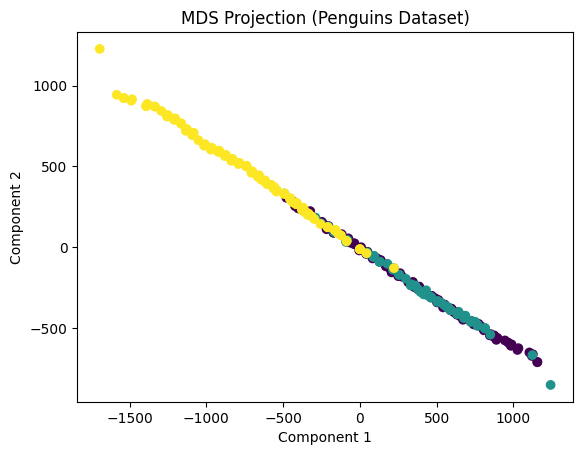

In [83]:
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y)
plt.title("MDS Projection (Penguins Dataset)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()